In [1]:
!pip install langdetect datasets matplotlib seaborn pillow tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=85d6b869973c8bcb6da16b935aa6e2e75d06d7ade44f2a5b35d7f7899654fdbb
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
from langdetect import detect, LangDetectException
import re
from tqdm import tqdm
from datasets import load_dataset



In [6]:
DS_NAME = "Pablinho/movies-dataset"

ds = load_dataset(DS_NAME, split="train", streaming=True)
rows = list(ds)
len(rows)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

9837

In [7]:
rows = list(ds.take(5000))
len(rows)


5000

In [9]:
import pandas as pd

df = pd.DataFrame(rows)
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [12]:
def clean_text(x):
    if x is None:
        return ""
    x = str(x)
    x = re.sub(r"<[^>]+>", "", x)
    x = x.replace("\n", " ").replace("\t", " ").strip()
    return x

df["Overview"] = df["Overview"].apply(clean_text)
df["Title"] = df["Title"].apply(clean_text)


In [13]:
df["overview_len"] = df["Overview"].apply(len)
df["overview_len"].describe()


,overview_len
count,5000.000000
mean,283.631200
std,151.761414
min,0.000000
25%,165.000000
50%,248.000000
75%,369.000000
max,1000.000000


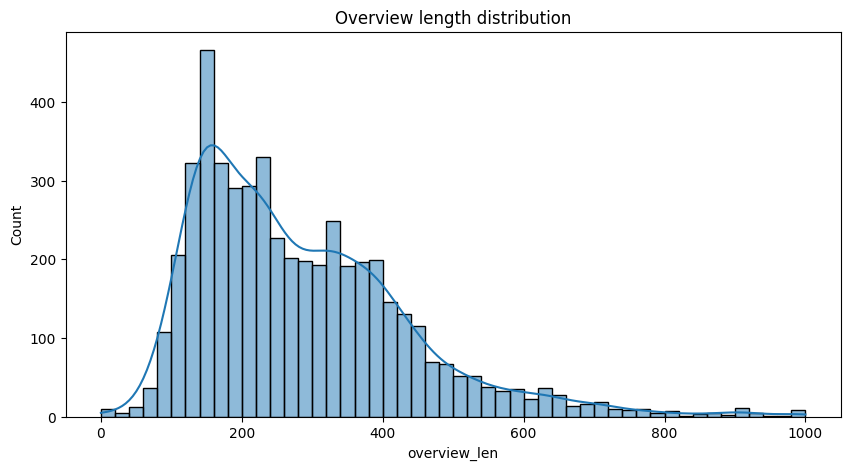

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["overview_len"], bins=50, kde=True)
plt.title("Overview length distribution")
plt.show()


In [15]:
bad_overviews = {"n/a", "na", "none", "coming soon", "-", ""}

def is_bad_overview(x):
    xl = x.lower().strip()
    if xl in bad_overviews:
        return True
    if len(set(xl)) < 10:
        return True
    return False

df["is_bad_overview"] = df["Overview"].apply(is_bad_overview)
df["is_bad_overview"].value_counts()


,count
is_bad_overview,
False,4990
True,10


In [16]:
df["Original_Language"].value_counts().head(20)


,count
Original_Language,
en,3946
ja,375
es,166
fr,94
ko,82
zh,60
it,41
cn,39
ru,35


In [17]:
def detect_lang_safe(text):
    try:
        return detect(text[:2000])
    except:
        return "unknown"

tqdm.pandas()
df["detected_lang"] = df["Overview"].progress_apply(detect_lang_safe)

df["detected_lang"].value_counts().head(20)


100%|██████████| 5000/5000 [00:14<00:00, 350.45it/s]


,count
detected_lang,
en,4987
unknown,10
es,3


In [18]:
df[df["detected_lang"] != "en"].head(10)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,overview_len,is_bad_overview,detected_lang
1106,- Just Desserts,,,NaN,None,None,None,None,None,0,True,unknown
1107,- If The Hue Fits,,,NaN,None,None,None,None,None,0,True,unknown
1108,- Dust Up,,,NaN,None,None,None,None,None,0,True,unknown
1109,- Scents And Sensibility,,,NaN,None,None,None,None,None,0,True,unknown
1110,- Just One Of The Girls,,,NaN,None,None,None,None,None,0,True,unknown
1111,- Volleybug,,,NaN,None,None,None,None,None,0,True,unknown
1112,- Hide And Tink,,,NaN,None,None,None,None,None,0,True,unknown
1113,- Rainbow's Ends,,,NaN,None,None,None,None,None,0,True,unknown
1114,- Fawn And Games,,,NaN,None,None,None,None,None,0,True,unknown
1115,- Magic Tricks,61.328,35,7.1,en,Animation,https://image.tmdb.org/t/p/original/6iXYe7AkQ1...,None,None,2,True,unknown


In [19]:
def parse_genres(x):
    if not isinstance(x, str):
        return []
    return [g.strip() for g in x.split(",") if g.strip()]

df["genres"] = df["Genre"].apply(parse_genres)
df["num_genres"] = df["genres"].apply(len)

df["num_genres"].describe()


,num_genres
count,5000.000000
mean,2.720600
std,1.144027
min,0.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,8.000000


In [21]:
from collections import Counter
genre_counter = Counter()

for glist in df["genres"]:
    genre_counter.update(glist)

genre_counter.most_common(20)


[('Action', 1633),
 ('Drama', 1588),
 ('Comedy', 1476),
 ('Thriller', 1269),
 ('Adventure', 1160),
 ('Animation', 969),
 ('Family', 874),
 ('Fantasy', 832),
 ('Science Fiction', 782),
 ('Horror', 765),
 ('Romance', 643),
 ('Crime', 570),
 ('Mystery', 388),
 ('History', 177),
 ('War', 134),
 ('Music', 112),
 ('TV Movie', 91),
 ('Documentary', 88),
 ('Western', 52)]

In [22]:
summary = {
    "total": len(df),
    "short_overview": (df["overview_len"] < 60).sum(),
    "bad_overview": df["is_bad_overview"].sum(),
    "non_english_detected": (df["detected_lang"] != "en").sum(),
    "original_language_not_en": (df["Original_Language"] != "en").sum(),
    "no_genres": (df["num_genres"] == 0).sum(),
}

summary


{'total': 5000,
 'short_overview': np.int64(27),
 'bad_overview': np.int64(10),
 'non_english_detected': np.int64(13),
 'original_language_not_en': np.int64(1054),
 'no_genres': np.int64(11)}

In [24]:
df[df.duplicated(subset=["Title"], keep=False)].head(20)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,overview_len,is_bad_overview,detected_lang,genres,num_genres,poster_ok
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...,222,False,en,"[Horror, Mystery, Thriller]",3,True
27,2022-02-10,Uncharted,"A young street-smart, Nathan Drake and his wis...",866.391,691,7.1,en,"Action, Adventure",https://image.tmdb.org/t/p/original/sqLowacltb...,227,False,en,"[Action, Adventure]",2,True
34,2021-12-08,West Side Story,Two youngsters from rival New York City gangs ...,678.186,562,7.4,en,"Drama, Romance, Crime",https://image.tmdb.org/t/p/original/yfz3IUoYYS...,127,False,en,"[Drama, Romance, Crime]",3,True
55,2021-04-07,Mortal Kombat,"Washed-up MMA fighter Cole Young, unaware of h...",402.273,4447,7.2,en,"Action, Fantasy, Adventure",https://image.tmdb.org/t/p/original/nkayOAUBUu...,269,False,en,"[Action, Fantasy, Adventure]",3,True
59,2021-09-15,Dune,"Paul Atreides, a brilliant and gifted young ma...",394.295,6237,7.9,en,"Science Fiction, Adventure",https://image.tmdb.org/t/p/original/d5NXSklXo0...,443,False,en,"[Science Fiction, Adventure]",2,True
72,1989-06-23,Batman,Batman must face his most ruthless nemesis whe...,338.272,6109,7.2,en,"Fantasy, Action",https://image.tmdb.org/t/p/original/jUhGHv4Yih...,141,False,en,"[Fantasy, Action]",2,True
78,2021-12-03,Diary of a Wimpy Kid,Greg Heffley is a scrawny but ambitious kid wi...,324.706,189,6.5,en,"Animation, Comedy, Family",https://image.tmdb.org/t/p/original/obg6lWuNaZ...,152,False,en,"[Animation, Comedy, Family]",3,True
138,2012-04-25,The Avengers,When an unexpected enemy emerges and threatens...,229.772,26490,7.7,en,"Science Fiction, Action, Adventure",https://image.tmdb.org/t/p/original/RYMX2wcKCB...,297,False,en,"[Science Fiction, Action, Adventure]",3,True
141,2016-10-25,Doctor Strange,"After his career is destroyed, a brilliant but...",228.266,18471,7.4,en,"Action, Adventure, Fantasy, Science Fiction",https://image.tmdb.org/t/p/original/uGBVj3bEbC...,178,False,en,"[Action, Adventure, Fantasy, Science Fiction]",4,True
162,2017-06-21,Ava,"Ava, 13, is spending the summer on the Atlanti...",210.438,130,6.0,fr,Drama,https://image.tmdb.org/t/p/original/cUI1PFsrQV...,325,False,en,[Drama],1,True


<Axes: xlabel='title_len', ylabel='Count'>

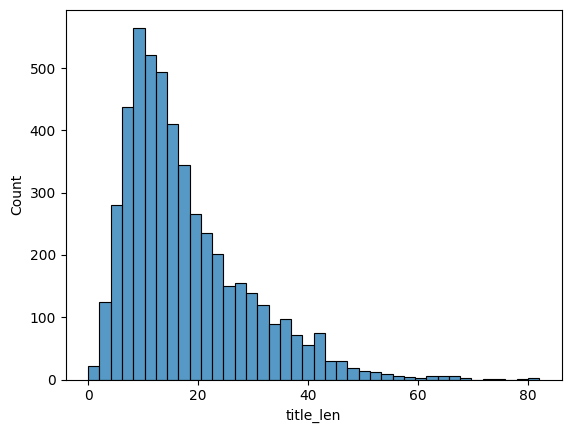

In [25]:
df["title_len"] = df["Title"].apply(len)
sns.histplot(df["title_len"], bins=40)


In [26]:
def is_weird_title(t):
    return bool(re.match(r"^[^A-Za-z0-9]+$", t))

df["weird_title"] = df["Title"].apply(is_weird_title)
df[df["weird_title"] == True].head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,overview_len,is_bad_overview,detected_lang,genres,num_genres,poster_ok,title_len,weird_title


In [27]:
pd.crosstab(df["Original_Language"], df["detected_lang"])


detected_lang,en,es,unknown
Original_Language,,,
ar,1,0,0
cn,39,0,0
da,6,0,0
de,23,0,0
en,3946,0,0
es,163,3,0
eu,1,0,0
fa,1,0,0
fi,2,0,0


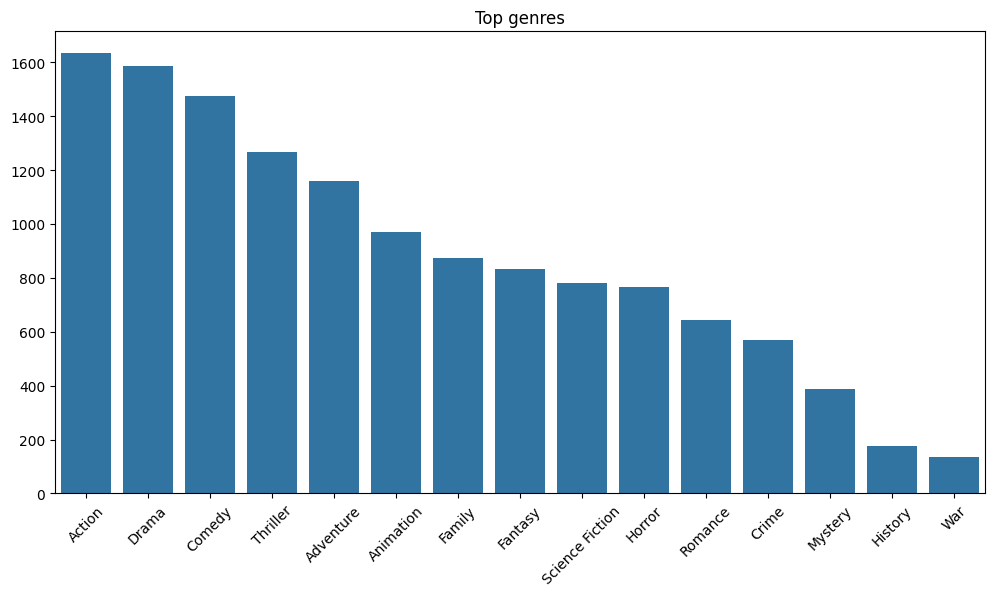

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(x=[g for g,_ in genre_counter.most_common(15)],
            y=[c for _,c in genre_counter.most_common(15)])
plt.xticks(rotation=45)
plt.title("Top genres")
plt.show()


In [30]:
df.isna().mean().sort_values(ascending=False)


,0
Genre,0.0022
Poster_Url,0.0022
Original_Language,0.0020
Vote_Count,0.0020
Popularity,0.0020
Vote_Average,0.0020
Release_Date,0.0000
Title,0.0000
Overview,0.0000
overview_len,0.0000


In [31]:
df["year"] = pd.to_datetime(df["Release_Date"], errors="coerce").dt.year
df["year"].describe()


,year
count,4990.000000
mean,2009.415431
std,12.800768
min,1922.000000
25%,2005.000000
50%,2013.000000
75%,2018.750000
max,2024.000000


<Axes: xlabel='Popularity', ylabel='Count'>

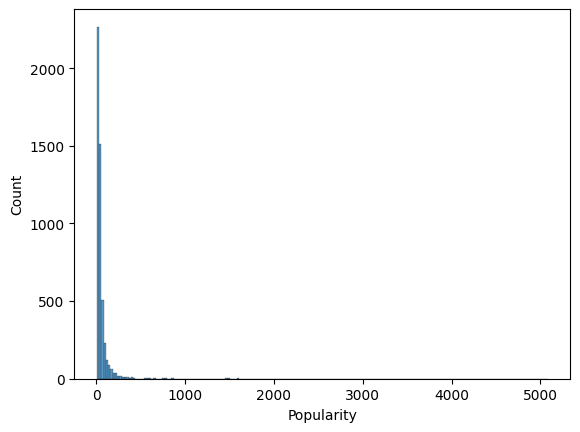

In [36]:
sns.histplot(df["Popularity"], bins=200)
